# Project Cycle 3: Two-Sample Inference
**Team Name:** [填寫你們的隊名]
**Team Members:** [填寫組員姓名]

## 1. Introduction & Research Questions
本專案旨在利用 YRBS 2007 資料集進行兩樣本推論 (Two-Sample Inference)。我們挑選了預先核准題庫中的 Question 6 進行分析：
* **群體變數 (Group Variable)**：`CurrentCigaretteUse` (目前是否有吸菸習慣，將重編碼為二元變數)。
* **反應變數 (Response Variable)**：`BMIPCT` (BMI 百分位數，連續數值變數)。
* **研究問題**：目前有吸菸習慣的學生與沒有吸菸習慣的學生，其平均 BMI 百分位數是否有顯著差異？

## 2. Setup & Data Loading
載入必要的 Python 套件，並讀取 YRBS_2007.csv 資料集。為了方便計算兩組差異的信賴區間，我們額外引入了 `statsmodels` 的 `CompareMeans`。

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW

# 設定繪圖風格
sns.set_theme(style="whitegrid")
# 忽略所有警告訊息
warnings.filterwarnings('ignore')

# 讀取原始資料
df = pd.read_csv('YRBS_2007.csv')
print(f"Dataset shape: {df.shape}")

NameError: name 'warnings' is not defined

## 3. Data Check & Recoding
在進行兩樣本比較前，我們必須先清理缺失值並將群體變數重編碼。
* 根據 Cycle 3 的重編碼規則，對於 `CurrentCigaretteUse`：
    * 代碼 `1` (0 days) 定義為失敗/對照組 (`0`)。
    * 代碼 `2-7` (1 or more days) 定義為成功/暴露組 (`1`)。
* 我們將同時排除 `CurrentCigaretteUse` 或 `BMIPCT` 含有遺失值 (NaN) 的資料，確保兩組樣本都有完整的群體與反應變數紀錄。

In [ ]:
# 提取我們需要的兩個變數並移除遺失值
df_clean = df.dropna(subset=['CurrentCigaretteUse', 'BMIPCT']).copy()

# 根據規則重編碼：1 為 0 (No), 2~7 為 1 (Yes)
def recode_cigarette(x):
    if x == 1:
        return 0
    elif x in [2, 3, 4, 5, 6, 7]:
        return 1
    else:
        return np.nan

df_clean['CurrentCigarette_Binary'] = df_clean['CurrentCigaretteUse'].apply(recode_cigarette)

# 移除重編碼後產生的無效值 (如果有原始資料代碼不在 1-7 範圍內)
df_clean = df_clean.dropna(subset=['CurrentCigarette_Binary'])

print(f"Cleaned sample size for analysis: {len(df_clean)}")

# 分割出兩組資料方便後續分析
group1_yes = df_clean[df_clean['CurrentCigarette_Binary'] == 1]['BMIPCT']
group0_no = df_clean[df_clean['CurrentCigarette_Binary'] == 0]['BMIPCT']

print(f"Sample size for Smokers (Group 1): {len(group1_yes)}")
print(f"Sample size for Non-Smokers (Group 0): {len(group0_no)}")

## 4. Exploratory Data Analysis (EDA)
在進行統計檢定前，我們先使用敘述性統計與圖表來觀察兩組學生的 BMIPCT 分佈差異。
本循環要求至少一張能清楚比較兩組的視覺化圖表，我們將使用 **盒鬚圖 (Boxplot)** 與 **分組敘述統計表**。

In [2]:
# 4.1 分組敘述性統計 (Summary Table)
summary_table = df_clean.groupby('CurrentCigarette_Binary')['BMIPCT'].describe()
print("--- Summary Statistics for BMIPCT by Group ---")
print(summary_table)

# 4.2 視覺化：多重圖表凸顯差異 (Distribution & Mean Comparison)
df_clean['Group_Label'] = df_clean['CurrentCigarette_Binary'].map({0: 'No (0)', 1: 'Yes (1)'})
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 圖表 1：小提琴圖 (Violin Plot) - 結合盒鬚圖與密度，觀察極端值與資料集中處
sns.violinplot(data=df_clean, x='Group_Label', y='BMIPCT', palette='Set2', ax=axes[0], inner="quartile")
axes[0].set_title('1. Violin Plot of BMIPCT', fontsize=12)
axes[0].set_xlabel('Current Cigarette Use')
axes[0].set_ylabel('BMI Percentile')

# 圖表 2：重疊核密度分佈圖 (KDE Plot) - 直觀比較兩組分佈曲線的「平移」現象
sns.kdeplot(data=df_clean[df_clean['CurrentCigarette_Binary'] == 0], x='BMIPCT', fill=True, label='No (0)', ax=axes[1], color='#fc8d62')
sns.kdeplot(data=df_clean[df_clean['CurrentCigarette_Binary'] == 1], x='BMIPCT', fill=True, label='Yes (1)', ax=axes[1], color='#66c2a5')
axes[1].set_title('2. Density Plot (KDE) of BMIPCT', fontsize=12)
axes[1].set_xlabel('BMI Percentile')
axes[1].set_ylabel('Density')
axes[1].legend(title='Cigarette Use')

# 圖表 3：帶有 95% 信賴區間的平均數點圖 (Point Plot) - 聚焦於平均數的差異
sns.pointplot(data=df_clean, x='Group_Label', y='BMIPCT', capsize=.1, err_kws={'linewidth': 2}, color='#333333', ax=axes[2])
axes[2].set_title('3. Mean BMIPCT with 95% CI', fontsize=12)
axes[2].set_xlabel('Current Cigarette Use')
axes[2].set_ylabel('Mean BMI Percentile')

plt.tight_layout()
plt.show()

sns.boxplot(data=df_clean, x='Group_Label', y='BMIPCT', palette='Set2')
plt.title('BMIPCT Distribution by Current Cigarette Use', fontsize=14)
plt.xlabel('Current Cigarette Use', fontsize=12)
plt.ylabel('BMI Percentile', fontsize=12)
plt.show()

NameError: name 'df_clean' is not defined

**EDA 觀察**：
> [請小組在這裡填寫觀察結果：從分組敘述性統計表來看，有吸菸組的平均 BMIPCT 是多少？沒有吸菸組的平均是多少？這兩者從數值上看起來相差大嗎？從盒鬚圖來看，兩組的中位數與資料散佈範圍是否有明顯的視覺差異？]

---
## 5. Statistical Inference (Two-Sample Inference)
因為反應變數 (`BMIPCT`) 為數值型，且我們要比較兩個獨立樣本的平均數，我們將使用 **Welch's Two-Sample t-test** (不假設變異數相等)。

* **定義群體**：
  * $\mu_1$：目前有吸菸學生的平均 BMI 百分位數 (Group 1)
  * $\mu_2$：目前無吸菸學生的平均 BMI 百分位數 (Group 0)
* **Null Hypothesis ($H_0$)**: $\mu_1 - \mu_2 = 0$ (兩組平均數沒有差異)
* **Alternative Hypothesis ($H_A$)**: $\mu_1 - \mu_2 \neq 0$ (兩組平均數有顯著差異)
* **Alpha level ($\alpha$)**: 0.05

Group 1 (Smokers) Mean: 66.2292
Group 0 (Non-Smokers) Mean: 64.3945
----------------------------------------
Estimated Difference in Means (Group 1 - Group 0): 1.8347
95% Confidence Interval for Difference: (0.6138, 3.0557)
Welch's T-statistic: 2.9463, p-value: 3.2359e-03


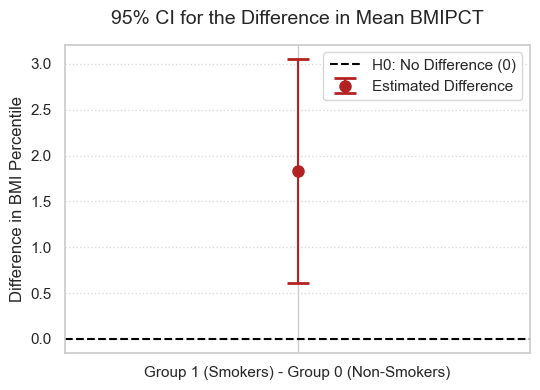

In [13]:
# 5.1 Welch's t-test (設定 equal_var=False)
t_stat, p_val = stats.ttest_ind(group1_yes, group0_no, equal_var=False)

# 5.2 計算差異的平均數 (Difference in Means: Group 1 - Group 0)
mean_diff = group1_yes.mean() - group0_no.mean()

# 5.3 計算 95% 差異信賴區間 (使用 statsmodels)
cm = CompareMeans(DescrStatsW(group1_yes), DescrStatsW(group0_no))
ci_low, ci_high = cm.tconfint_diff(alpha=0.05, usevar='unequal')

# 輸出統整結果
print(f"Group 1 (Smokers) Mean: {group1_yes.mean():.4f}")
print(f"Group 0 (Non-Smokers) Mean: {group0_no.mean():.4f}")
print("-" * 40)
print(f"Estimated Difference in Means (Group 1 - Group 0): {mean_diff:.4f}")
print(f"95% Confidence Interval for Difference: ({ci_low:.4f}, {ci_high:.4f})")
print(f"Welch's T-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")

# 5.4 視覺化：差異的信賴區間圖 (Confidence Interval Plot for the Group Difference)
plt.figure(figsize=(6, 4))

# 計算誤差棒的單邊長度 (Margin of Error)
yerr = (ci_high - ci_low) / 2

# 繪製誤差棒與差異平均值點
plt.errorbar(x=[0], y=[mean_diff], yerr=[yerr], fmt='o', color='firebrick', 
             capsize=8, capthick=2, markersize=8, label='Estimated Difference')

# 畫出虛無假設的基準線 (Difference = 0)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='H0: No Difference (0)')

# 圖表格式設定
plt.xticks([0], ['Group 1 (Smokers) - Group 0 (Non-Smokers)'])
plt.xlim(-0.5, 0.5)
plt.title('95% CI for the Difference in Mean BMIPCT', fontsize=14, pad=15)
plt.ylabel('Difference in BMI Percentile')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.show()

**推論詮釋 (Interpretation of Difference)**：
> [請小組填寫：
> 1. 哪一組的平均數比較高？
> 2. 兩組的差異 ($\bar{x}_1 - \bar{x}_2$) 多大？
> 3. 信賴區間是否包含 0？p-value 是否小於 0.05？
> 4. 因此我們決定（拒絕 / 不拒絕）虛無假設。這代表我們（有 / 沒有）足夠證據宣稱兩群學生的 BMI 百分位數平均值有顯著差異。]

---
## 6. Conclusion
> [請小組填寫最終結論：結合情境解釋這個結果。例如：「我們透過 Welch's t-test 比較了...，結果發現這兩組在 BMI 百分位數上（有 / 沒有）統計上的顯著差異。具體來說，目前有吸菸習慣的學生，其平均 BMI 百分位數比沒有吸菸習慣的學生（高/低）了約 ___ 個百分位。不過我們也要注意這僅是觀察性調查，無法推論出吸菸與體重之間的因果關係...」]